# Black Swan V5 - Date cu Macro Features
**Ce e nou fata de V4:**
- 5 features macro externe din FRED API
- Matrice de corelatie features vs features
- Tot restul identic cu V4 (weekly, binary, acelasi split)

## 1. Import Librarii

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Instalare fredapi daca nu e prezenta
# !pip install fredapi
from fredapi import Fred

os.makedirs('plots', exist_ok=True)

print('Librarii incarcate.')

Librarii incarcate.


## 2. FRED API Key

Introdu API key-ul tau FRED mai jos.  
Il obtii gratuit de la: https://fred.stlouisfed.org/docs/api/api_key.html

In [2]:
FRED_API_KEY = '9cbb31e1e8aeea0f649895cfc852dce7'

fred = Fred(api_key=FRED_API_KEY)
print('FRED API conectat.')

FRED API conectat.


## 3. Definitia Evenimentelor (identic V4)

In [3]:
EVENTS = [
    {'name': 'Dotcom Crash',           'start': '2000-01-01', 'end': '2002-10-31', 'category': 'Grey Swan'},
    {'name': 'Global Financial Crisis','start': '2008-01-01', 'end': '2009-06-30', 'category': 'Grey Swan'},
    {'name': 'European Debt Crisis',   'start': '2011-04-01', 'end': '2011-12-31', 'category': 'Grey Swan'},
    {'name': 'Taper Tantrum',          'start': '2013-04-01', 'end': '2013-10-31', 'category': 'Grey Swan'},
    {'name': 'China Devaluation',      'start': '2015-06-01', 'end': '2016-02-28', 'category': 'Grey Swan'},
    {'name': 'Fed Rate Hikes 2022',    'start': '2022-01-01', 'end': '2022-12-31', 'category': 'Grey Swan'},
    {'name': 'Liberation Day Tariffs', 'start': '2025-02-01', 'end': '2025-08-01', 'category': 'Grey Swan'},
    {'name': 'COVID Crash',            'start': '2020-01-15', 'end': '2020-08-31', 'category': 'Black Swan'},
    {'name': '9/11',                   'start': '2001-07-01', 'end': '2001-12-31', 'category': 'Black Swan'},
    {'name': 'Flash Crash',            'start': '2010-04-01', 'end': '2010-08-31', 'category': 'Black Swan'},
]

print('Evenimente:', len(EVENTS))

Evenimente: 10


## 4. Descarcare Date SP500 si VIX (identic V4)

In [4]:
sp500_raw = yf.download('^GSPC', start='1999-01-01', end='2025-09-01', auto_adjust=True)
sp500_raw = sp500_raw[['Close', 'Volume']].copy()
sp500_raw.columns = ['SP500_Close', 'SP500_Volume']

vix_raw = yf.download('^VIX', start='1999-01-01', end='2025-09-01', auto_adjust=True)
vix_raw = vix_raw[['Close']].copy()
vix_raw.columns = ['VIX_raw']

daily = sp500_raw.join(vix_raw, how='left')
daily.index = pd.to_datetime(daily.index)

print('SP500 + VIX descarcate:', daily.index[0].date(), '->', daily.index[-1].date())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

SP500 + VIX descarcate: 1999-01-04 -> 2025-08-29


## 5. Descarcare Date Macro din FRED

| Serie | Cod FRED | Frecventa | Ce masoara |
|---|---|---|---|
| Yield Curve | T10Y2Y | Zilnic | Spread 10Y-2Y, negativ = recesiune |
| Jobless Claims | ICSA | Saptamanal | Somaj initial, spike = economie slaba |
| Credit Spread HY | BAMLH0A0HYM2 | Zilnic | Spread obligatiuni HY vs Treasury |
| Dollar Index | DTWEXBGS | Zilnic | Puterea dolarului |
| Fed Funds Rate | FEDFUNDS | Lunar | Dobanda de referinta Fed |

In [5]:
START = '1999-01-01'
END   = '2025-09-01'

fred_series = {
    'Yield_Curve'   : 'T10Y2Y',
    'Jobless_Claims': 'ICSA',
    'Credit_Spread' : 'BAMLH0A0HYM2',
    'Dollar_Index'  : 'DTWEXM',
    'Fed_Rate'      : 'FEDFUNDS'
}

macro_daily = pd.DataFrame()

for name, code in fred_series.items():
    try:
        series = fred.get_series(code, observation_start=START, observation_end=END)
        series.name = name
        macro_daily = macro_daily.join(series, how='outer') if not macro_daily.empty else series.to_frame()
        print(name.ljust(20), ':', len(series), 'observatii | Ultima valoare:', round(series.dropna().iloc[-1], 3))
    except Exception as e:
        print('EROARE la', name, ':', e)

macro_daily.index = pd.to_datetime(macro_daily.index)

# Forward fill pentru date lunare si saptamanale (Fed Rate, Jobless Claims)
macro_daily = macro_daily.ffill()

print('\nDate macro descarcate:', macro_daily.shape)
macro_daily.tail(3)

Yield_Curve          : 6957 observatii | Ultima valoare: 0.64
Jobless_Claims       : 1392 observatii | Ultima valoare: 236000.0
Credit_Spread        : 7047 observatii | Ultima valoare: 2.84
Dollar_Index         : 5478 observatii | Ultima valoare: 90.822
Fed_Rate             : 321 observatii | Ultima valoare: 4.22

Date macro descarcate: (8440, 5)


,Yield_Curve,Jobless_Claims,Credit_Spread,Dollar_Index,Fed_Rate
2025-08-30,0.64,236000.0,2.82,90.8221,4.33
2025-08-31,0.64,236000.0,2.84,90.8221,4.33
2025-09-01,0.64,236000.0,2.84,90.8221,4.22


## 6. Feature Engineering pe Date Zilnice

In [6]:
# Join SP500 cu macro
df = daily.join(macro_daily, how='left').ffill()

# Features V4 (identice)
df['MA50']             = df['SP500_Close'].rolling(50).mean()
df['MA200']            = df['SP500_Close'].rolling(200).mean()
df['Dist_MA50']        = (df['SP500_Close'] - df['MA50'])  / df['MA50']
df['Dist_MA200']       = (df['SP500_Close'] - df['MA200']) / df['MA200']
df['Dist_52w_High']    = (df['SP500_Close'] - df['SP500_Close'].rolling(252).max()) / df['SP500_Close'].rolling(252).max()
df['Return_1d']        = df['SP500_Close'].pct_change()
df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)
df['Local_Min_20d']    = df['SP500_Close'].rolling(20).min()
df['Dist_Local_Min']   = (df['SP500_Close'] - df['Local_Min_20d']) / df['Local_Min_20d']
df['VIX_MA60']         = df['VIX_raw'].rolling(60).mean()
df['VIX_Ratio']        = df['VIX_raw'] / df['VIX_MA60']

def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['SP500_Close'])

def rolling_slope(series, window):
    slopes = [np.nan] * len(series)
    vals   = series.values
    x      = np.arange(window)
    for i in range(window - 1, len(vals)):
        y = vals[i - window + 1 : i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(x, y, 1)[0]
    return pd.Series(slopes, index=series.index)

df['VIX_Trend_20d']   = rolling_slope(df['VIX_raw'], 20)
df['SP500_Trend_20d'] = rolling_slope(df['SP500_Close'], 20)

# Features macro noi V5
# Yield curve: schimbarea pe 4 saptamani (trendul conteaza mai mult decat nivelul)
df['Yield_Curve_Change'] = df['Yield_Curve'].diff(20)

# Jobless claims: schimbare procentuala fata de media 12 saptamani
df['Jobless_MA12']       = df['Jobless_Claims'].rolling(60).mean()
df['Jobless_Ratio']      = df['Jobless_Claims'] / df['Jobless_MA12']

# Credit spread: nivelul absolut (spread mare = frica)
# Deja disponibil ca Credit_Spread

# Dollar: schimbare pe 4 saptamani
df['Dollar_Change']      = df['Dollar_Index'].pct_change(20)

# Forward return + label
df['Forward_Return_60d'] = df['SP500_Close'].shift(-60) / df['SP500_Close'] - 1
df['label_daily']        = (df['Forward_Return_60d'] > 0.05).astype(float)

print('Features calculate.')
print('Features V4: 14 | Features macro noi V5: 5')

Features calculate.
Features V4: 14 | Features macro noi V5: 5


## 7. Agregare Saptamanala

In [7]:
agg_rules = {
    # V4 features
    'SP500_Close'     : 'last',
    'SP500_Volume'    : 'sum',
    'VIX_raw'         : 'mean',
    'Dist_MA50'       : 'last',
    'Dist_MA200'      : 'last',
    'Dist_52w_High'   : 'last',
    'RSI'             : 'last',
    'Dist_Local_Min'  : 'last',
    'VIX_Ratio'       : 'mean',
    'VIX_Trend_20d'   : 'mean',
    'SP500_Trend_20d' : 'last',
    'Realized_Vol_10d': 'mean',
    # Macro V5
    'Yield_Curve'     : 'mean',
    'Yield_Curve_Change': 'last',
    'Jobless_Ratio'   : 'mean',
    'Credit_Spread'   : 'mean',
    'Dollar_Change'   : 'last',
    'Fed_Rate'        : 'last',
    # Label
    'label_daily'     : lambda x: x.mode()[0] if len(x) > 0 else np.nan
}

weekly = df.resample('W-FRI').agg(agg_rules)
weekly = weekly.rename(columns={'VIX_raw': 'VIX'})

weekly['Return_1w']    = weekly['SP500_Close'].pct_change()
weekly['Return_4w']    = weekly['SP500_Close'].pct_change(4)
weekly['Volume_Ratio'] = weekly['SP500_Volume'] / weekly['SP500_Volume'].rolling(8).mean()
weekly['label']        = weekly['label_daily'].astype(int)

weekly = weekly.loc[:, ~weekly.columns.duplicated()]
weekly.dropna(subset=['Return_1w', 'label'], inplace=True)
weekly = weekly.ffill()

print('Date saptamanale:', len(weekly), 'saptamani')
print('Missing values per coloana macro:')
macro_cols = ['Yield_Curve', 'Yield_Curve_Change', 'Jobless_Ratio', 'Credit_Spread', 'Dollar_Change', 'Fed_Rate']
print(weekly[macro_cols].isnull().sum())

Date saptamanale: 1390 saptamani
Missing values per coloana macro:
Yield_Curve            0
Yield_Curve_Change     3
Jobless_Ratio         11
Credit_Spread          0
Dollar_Change          3
Fed_Rate               0
dtype: int64


## 8. Constructie Dataset

In [8]:
feature_cols_v4 = [
    'Return_1w', 'Return_4w', 'Dist_MA50', 'Dist_MA200',
    'Dist_52w_High', 'Dist_Local_Min',
    'VIX', 'VIX_Ratio', 'VIX_Trend_20d',
    'Realized_Vol_10d', 'Volume_Ratio',
    'RSI', 'SP500_Trend_20d', 'Phase'
]

feature_cols_macro = [
    'Yield_Curve', 'Yield_Curve_Change',
    'Jobless_Ratio', 'Credit_Spread',
    'Dollar_Change', 'Fed_Rate'
]

feature_cols = feature_cols_v4 + feature_cols_macro

all_windows = []

for event in EVENTS:
    mask   = (weekly.index >= event['start']) & (weekly.index <= event['end'])
    window = weekly.loc[mask].copy()

    if len(window) == 0:
        continue

    n      = len(window)
    phases = [1 if i <= 6 else (2 if i <= 18 else 3) for i in range(n)]
    window['Phase']         = phases
    window['event_name']    = event['name']
    window['category']      = event['category']
    window['week_relative'] = range(n)
    all_windows.append(window)

dataset = pd.concat(all_windows)
dataset = dataset.dropna(subset=feature_cols + ['label'])

print('Dataset final:', len(dataset), 'saptamani')
counts = dataset['label'].value_counts()
print('Non-V (0):   ', counts.get(0, 0), '(' + str(round(counts.get(0,0)/len(dataset)*100, 1)) + '%)')
print('V-shape (1): ', counts.get(1, 0), '(' + str(round(counts.get(1,0)/len(dataset)*100, 1)) + '%)')

Dataset final: 493 saptamani
Non-V (0):    358 (72.6%)
V-shape (1):  135 (27.4%)


## 9. Matrice de Corelatie

Vizualizam corelatiile intre toate features pentru a detecta:
- **Features redundante** (corelatie > 0.8): pot fi eliminate
- **Features independente**: adauga informatie unica
- **Cum se coreleaza macro cu features tehnice**

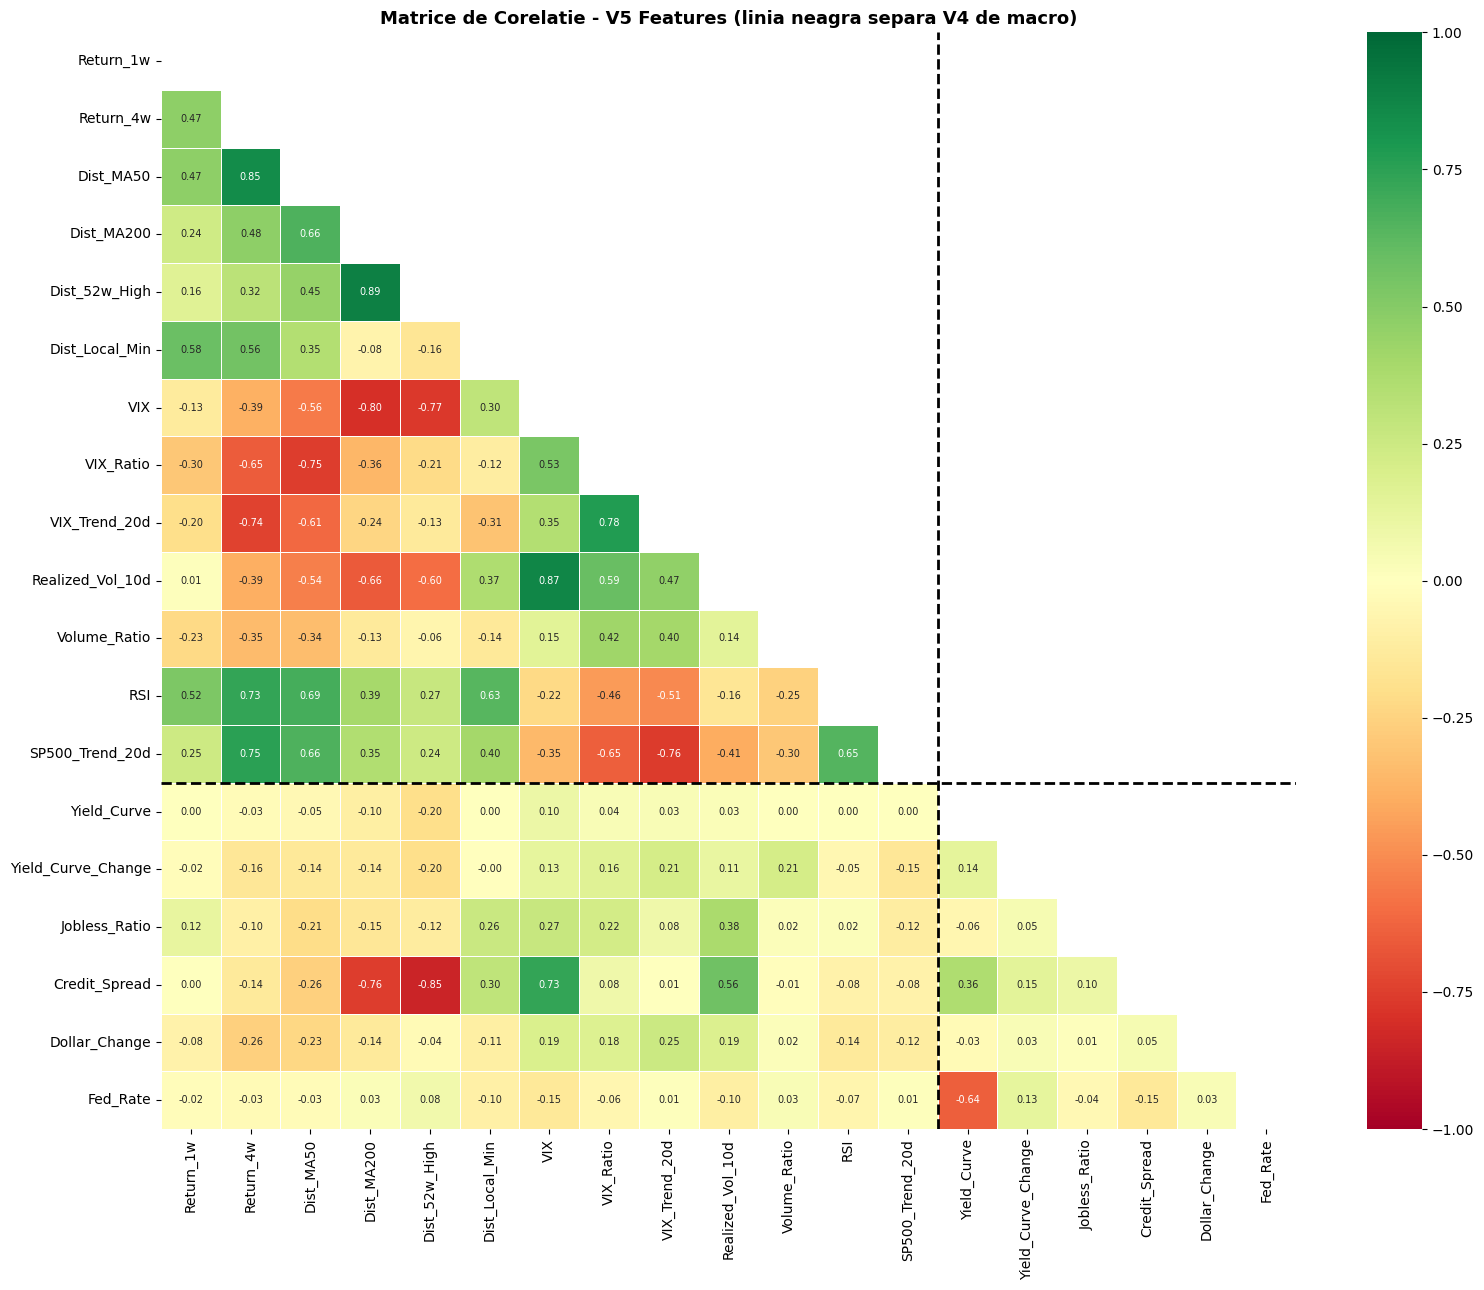

Salvat: plots/V5_correlation_matrix.png


In [9]:
# Calculam matricea de corelatie pe intregul dataset
corr_cols  = [f for f in feature_cols if f != 'Phase']
corr_matrix = dataset[corr_cols].corr()

# Heatmap principal
fig, ax = plt.subplots(figsize=(16, 13))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True   # ascundem triunghiul superior (duplicat)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)

# Marcam features macro cu o linie de separare
n_v4    = len([f for f in corr_cols if f in feature_cols_v4])
n_macro = len([f for f in corr_cols if f in feature_cols_macro])
ax.axhline(n_v4, color='black', linewidth=2, linestyle='--')
ax.axvline(n_v4, color='black', linewidth=2, linestyle='--')

ax.set_title('Matrice de Corelatie - V5 Features (linia neagra separa V4 de macro)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/V5_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/V5_correlation_matrix.png')

## 10. Corelatie Features cu Label

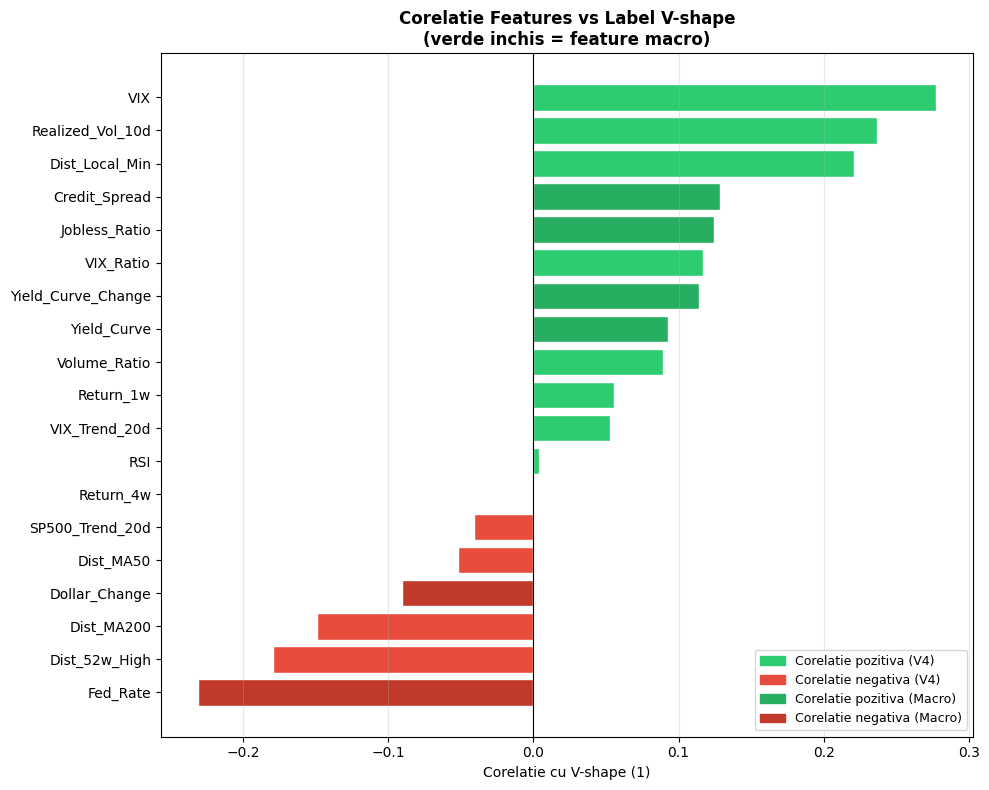

Salvat: plots/V5_label_correlation.png

Top 5 features cel mai corelate cu V-shape:
VIX                 0.277472
Realized_Vol_10d    0.237025
Fed_Rate            0.231178
Dist_Local_Min      0.220619
Dist_52w_High       0.179722
Name: label, dtype: float64


In [10]:
label_corr = dataset[corr_cols + ['label']].corr()['label'].drop('label').sort_values()

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in label_corr.values]
colors_macro = ['#c0392b' if (v < 0 and f in feature_cols_macro) else
                '#27ae60' if (v >= 0 and f in feature_cols_macro) else c
                for f, v, c in zip(label_corr.index, label_corr.values, colors)]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(label_corr.index, label_corr.values, color=colors_macro, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Corelatie cu V-shape (1)')
ax.set_title('Corelatie Features vs Label V-shape\n(verde inchis = feature macro)', 
             fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend = [
    Patch(color='#2ecc71', label='Corelatie pozitiva (V4)'),
    Patch(color='#e74c3c', label='Corelatie negativa (V4)'),
    Patch(color='#27ae60', label='Corelatie pozitiva (Macro)'),
    Patch(color='#c0392b', label='Corelatie negativa (Macro)'),
]
ax.legend(handles=legend, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('plots/V5_label_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/V5_label_correlation.png')
print('\nTop 5 features cel mai corelate cu V-shape:')
print(label_corr.abs().sort_values(ascending=False).head(5))

## 11. Train / Test Split

In [11]:
TRAIN_EVENTS = [
    'Global Financial Crisis', 'European Debt Crisis',
    'Taper Tantrum', 'China Devaluation', '9/11', 'Flash Crash'
]
TEST_EVENTS = [
    'Fed Rate Hikes 2022', 'COVID Crash', 'Liberation Day Tariffs'
]

dotcom_all   = dataset[dataset['event_name'] == 'Dotcom Crash']
dotcom_train = dotcom_all.iloc[:-40]
dotcom_test  = dotcom_all.iloc[-40:]

train_df = pd.concat([dotcom_train, dataset[dataset['event_name'].isin(TRAIN_EVENTS)]])
test_df  = pd.concat([dotcom_test,  dataset[dataset['event_name'].isin(TEST_EVENTS)]])

train_df = train_df.dropna(subset=feature_cols)
test_df  = test_df.dropna(subset=feature_cols)

print('Train:', len(train_df), 'saptamani')
print('Test: ', len(test_df),  'saptamani')

for split_name, split in [('Train', train_df), ('Test', test_df)]:
    c = split['label'].value_counts()
    print('\nDistributie', split_name + ':')
    print('  Non-V (0):  ', c.get(0, 0))
    print('  V-shape (1):', c.get(1, 0))

Train: 342 saptamani
Test:  151 saptamani

Distributie Train:
  Non-V (0):   254
  V-shape (1): 88

Distributie Test:
  Non-V (0):   104
  V-shape (1): 47


## 12. Salvare Dataset

In [12]:
dataset.to_csv('V5_dataset.csv')
train_df.to_csv('V5_train.csv')
test_df.to_csv('V5_test.csv')

with open('V5_feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

meta = {
    'feature_cols_v4'   : feature_cols_v4,
    'feature_cols_macro': feature_cols_macro,
    'feature_cols'      : feature_cols,
    'v_threshold'       : 0.05,
    'forward_days'      : 60,
    'frequency'         : 'weekly'
}
with open('V5_data_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Fisiere salvate:')
print('  V5_dataset.csv  ->', len(dataset), 'saptamani')
print('  V5_train.csv    ->', len(train_df), 'saptamani')
print('  V5_test.csv     ->', len(test_df), 'saptamani')
print('  V5_feature_cols.json')
print('  V5_data_meta.json')
print('\nTotal features V5:', len(feature_cols))
print('  V4 features:', len(feature_cols_v4))
print('  Macro noi:  ', len(feature_cols_macro))
print('\nGata pentru V5_modeling.ipynb')

Fisiere salvate:
  V5_dataset.csv  -> 493 saptamani
  V5_train.csv    -> 342 saptamani
  V5_test.csv     -> 151 saptamani
  V5_feature_cols.json
  V5_data_meta.json

Total features V5: 20
  V4 features: 14
  Macro noi:   6

Gata pentru V5_modeling.ipynb
